# Figure 2 all-in-one simulation, fitting, visualization, and metrics

Run this notebook top-to-bottom to regenerate the four selected synthetic examples, fit the three methods, show a comparison grid, export the four slide-ready PDFs, and print the manifold-projection distance metrics. Tune ManfitVelo in the parameter cell below.

## Setup

In [1]:

%load_ext autoreload
%autoreload 2

from pathlib import Path
import json
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
import numpy as np
from sklearn.neighbors import NearestNeighbors

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "simulations":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
elif PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figure2_pipeline"
DATA_DIR = OUTPUT_DIR / "simulated_data"

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "Arial",
    "font.size": 8,
    "axes.titlesize": 8,
    "axes.linewidth": 0.55,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


## Shared plotting and save/load helpers

In [2]:
def normalize01(values):
    values = np.asarray(values, dtype=float)
    return (values - values.min()) / (values.max() - values.min() + 1e-12)


def normalize_rows(values):
    values = np.asarray(values, dtype=float)
    return values / (np.linalg.norm(values, axis=1, keepdims=True) + 1e-12)


# Arrow selection knobs: use the original occupied-bin grid, then save the selected cell ids.
# These same ids are reused across noisy data and all benchmark methods.
ARROW_GRID_2D = 7
ARROW_GRID_3D = 5
MAX_ARROWS_2D = 48
MAX_ARROWS_3D = 42


def choose_arrow_indices_2d(x2, n_bins=ARROW_GRID_2D, max_arrows=MAX_ARROWS_2D):
    x2 = np.asarray(x2, dtype=float)
    x = x2[:, 0]
    y = x2[:, 1]
    bx = np.clip(np.digitize(x, np.linspace(x.min(), x.max(), n_bins + 1)) - 1, 0, n_bins - 1)
    by = np.clip(np.digitize(y, np.linspace(y.min(), y.max(), n_bins + 1)) - 1, 0, n_bins - 1)
    chosen = []
    for i in range(n_bins):
        for j in range(n_bins):
            members = np.flatnonzero((bx == i) & (by == j))
            if members.size == 0:
                continue
            center = np.array([
                x.min() + (i + 0.5) * (x.max() - x.min()) / n_bins,
                y.min() + (j + 0.5) * (y.max() - y.min()) / n_bins,
            ])
            chosen.append(members[np.argmin(np.linalg.norm(x2[members] - center, axis=1))])
    chosen = np.asarray(chosen, dtype=int)
    if chosen.size > max_arrows:
        chosen = chosen[np.linspace(0, chosen.size - 1, max_arrows).round().astype(int)]
    return chosen


def choose_arrow_indices_3d(x_mat, n_bins=ARROW_GRID_3D, max_arrows=MAX_ARROWS_3D):
    x_mat = np.asarray(x_mat, dtype=float)
    mins = x_mat.min(axis=0)
    maxs = x_mat.max(axis=0)
    spans = np.maximum(maxs - mins, 1e-12)
    bins = np.clip(((x_mat - mins) / spans * n_bins).astype(int), 0, n_bins - 1)
    chosen = []
    for i in range(n_bins):
        for j in range(n_bins):
            for k in range(n_bins):
                members = np.flatnonzero((bins[:, 0] == i) & (bins[:, 1] == j) & (bins[:, 2] == k))
                if members.size == 0:
                    continue
                center = mins + (np.array([i, j, k]) + 0.5) * spans / n_bins
                chosen.append(members[np.argmin(np.linalg.norm(x_mat[members] - center, axis=1))])
    chosen = np.asarray(chosen, dtype=int)
    if chosen.size > max_arrows:
        chosen = chosen[np.linspace(0, chosen.size - 1, max_arrows).round().astype(int)]
    return chosen


def assign_arrow_indices(sim):
    x_mat = np.asarray(sim["X"], dtype=float)
    if x_mat.shape[1] == 3:
        sim["arrow_indices"] = choose_arrow_indices_3d(x_mat)
    else:
        sim["arrow_indices"] = choose_arrow_indices_2d(x_mat)
    return sim


def visible_half_sphere_arrow_indices(sim, arrow_idx):
    x_mat = np.asarray(sim["X"], dtype=float)
    if sim.get("name") != "half_sphere_single_basin" or x_mat.shape[1] != 3:
        return arrow_idx
    if arrow_idx.size == 0:
        return arrow_idx

    view = sim.get("view") or {}
    azim = np.deg2rad(float(view.get("azim", -58)))
    camera_xy = np.array([np.cos(azim), np.sin(azim)])
    centered_xy = x_mat[:, :2] - x_mat[:, :2].mean(axis=0, keepdims=True)
    depth = centered_xy @ camera_xy
    near_side = depth[arrow_idx] >= np.median(depth)
    return arrow_idx[near_side]


def sparse_swiss_roll_arrow_indices(sim, arrow_idx, max_arrows=24):
    if sim.get("name") != "swiss_roll_velocity_flow" or arrow_idx.size <= max_arrows:
        return arrow_idx
    keep = np.linspace(0, arrow_idx.size - 1, max_arrows).round().astype(int)
    return arrow_idx[keep]


def arrow_indices_for_plot(sim):
    if "arrow_indices" in sim:
        arrow_idx = np.asarray(sim["arrow_indices"], dtype=int)
    else:
        x_mat = np.asarray(sim["X"], dtype=float)
        if x_mat.shape[1] == 3:
            arrow_idx = choose_arrow_indices_3d(x_mat)
        else:
            arrow_idx = choose_arrow_indices_2d(x_mat)
    arrow_idx = visible_half_sphere_arrow_indices(sim, arrow_idx)
    return sparse_swiss_roll_arrow_indices(sim, arrow_idx)

def equalize_limits_2d(ax, x2, pad=0.10):
    xmin, ymin = x2.min(axis=0)
    xmax, ymax = x2.max(axis=0)
    span = max(xmax - xmin, ymax - ymin)
    xmid = 0.5 * (xmin + xmax)
    ymid = 0.5 * (ymin + ymax)
    ax.set_xlim(xmid - 0.5 * span * (1 + pad), xmid + 0.5 * span * (1 + pad))
    ax.set_ylim(ymid - 0.5 * span * (1 + pad), ymid + 0.5 * span * (1 + pad))


def equalize_limits_3d(ax, x_mat, pad=-0.18):
    mins = x_mat.min(axis=0)
    maxs = x_mat.max(axis=0)
    centers = 0.5 * (mins + maxs)
    span = np.max(maxs - mins) * (1 + pad)
    ax.set_xlim(centers[0] - 0.5 * span, centers[0] + 0.5 * span)
    ax.set_ylim(centers[1] - 0.5 * span, centers[1] + 0.5 * span)
    ax.set_zlim(centers[2] - 0.5 * span, centers[2] + 0.5 * span)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def style_2d_axis(ax):
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


def style_3d_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.grid(False)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_alpha(0)
        axis.pane.set_edgecolor("white")
        axis.line.set_color((1, 1, 1, 0))
    ax.set_facecolor("white")


def draw_half_sphere_surface(ax, x_mat, color="#cbd5e1"):
    theta = np.linspace(0, 2 * np.pi, 96)
    rho = np.linspace(0, 1.0, 36)
    rr, tt = np.meshgrid(rho, theta, indexing="ij")
    u = rr * np.cos(tt)
    v = rr * np.sin(tt)
    z = np.sqrt(np.maximum(1.0 - rr**2, 0.0))
    center = np.asarray(x_mat, dtype=float).mean(axis=0)
    ax.plot_surface(
        u - center[0],
        v - center[1],
        z - center[2],
        color=color,
        alpha=0.42,
        linewidth=0,
        antialiased=True,
        shade=False,
        zorder=1,
    )


def draw_saddle_chip_surface(ax, x_mat, color="#cbd5e1"):
    theta = np.linspace(0, 2 * np.pi, 96)
    rho = np.linspace(0, 1.12, 36)
    rr, tt = np.meshgrid(rho, theta, indexing="ij")
    u = rr * np.cos(tt)
    w = rr * np.sin(tt)
    y = 0.55 * (u**2 - w**2)
    center = np.asarray(x_mat, dtype=float).mean(axis=0)
    ax.plot_surface(
        u - center[0],
        y - center[1],
        w - center[2],
        color=color,
        alpha=0.48,
        linewidth=0,
        antialiased=True,
        shade=False,
        zorder=1,
    )


def plot_simulation_panel(ax, sim):
    color = normalize01(sim["color"])
    if sim["name"] == "half_sphere_single_basin":
        color = 0.18 + 0.82 * color
    cmap = "viridis" if sim["family"] == "Velocity" else "magma_r"
    if sim["X"].shape[1] == 3:
        x_mat = sim["X"] - sim["X"].mean(axis=0)
        v_mat = normalize_rows(sim["V"])
        if sim["name"] == "half_sphere_single_basin":
            draw_half_sphere_surface(ax, sim["X"])
        elif sim["name"] == "saddle_surface_single_basin":
            draw_saddle_chip_surface(ax, sim["X"])
        ax.scatter(
            x_mat[:, 0], x_mat[:, 1], x_mat[:, 2],
            c=color, cmap=cmap, vmin=0, vmax=1,
            s=13, alpha=0.78, linewidths=0, rasterized=True, depthshade=False, zorder=1,
        )
        arrow_idx = arrow_indices_for_plot(sim)
        span = np.max(np.ptp(x_mat, axis=0))
        is_swiss = sim["name"] == "swiss_roll_velocity_flow"
        arrow_length = (0.125 if is_swiss else 0.18) * span
        ax.quiver(
            x_mat[arrow_idx, 0], x_mat[arrow_idx, 1], x_mat[arrow_idx, 2],
            v_mat[arrow_idx, 0], v_mat[arrow_idx, 1], v_mat[arrow_idx, 2],
            length=arrow_length, normalize=True,
            color="#050505", alpha=0.98,
            linewidth=0.95 if is_swiss else 1.45,
            arrow_length_ratio=0.36 if is_swiss else 0.48, zorder=20,
        )
        limit_pad = -0.34 if sim["family"] == "Potential" else -0.18
        equalize_limits_3d(ax, x_mat, pad=limit_pad)
        view = sim.get("view") or {"elev": 22, "azim": -58, "roll": 0}
        try:
            ax.view_init(elev=view["elev"], azim=view["azim"], roll=view.get("roll", 0))
        except TypeError:
            ax.view_init(elev=view["elev"], azim=view["azim"])
        style_3d_axis(ax)
    else:
        x2 = np.asarray(sim["X"], dtype=float)
        v2 = normalize_rows(sim["V"])
        ax.scatter(
            x2[:, 0], x2[:, 1],
            c=color, cmap=cmap, vmin=0, vmax=1,
            s=12, alpha=0.72, linewidths=0, rasterized=True, zorder=1,
        )
        arrow_idx = arrow_indices_for_plot(sim)
        span = max(np.ptp(x2[:, 0]), np.ptp(x2[:, 1]))
        ax.quiver(
            x2[arrow_idx, 0], x2[arrow_idx, 1],
            v2[arrow_idx, 0], v2[arrow_idx, 1],
            angles="xy", scale_units="xy", scale=8.2 / span,
            width=0.010, headwidth=4.4, headlength=6.0, headaxislength=5.0,
            color="#171717", alpha=0.96, zorder=20,
        )
        equalize_limits_2d(ax, x2)
        style_2d_axis(ax)


def add_group_labels(fig, y=1.01):
    fig.text(0.26, y, "Velocity fields", ha="center", va="bottom", fontsize=8, weight="bold")
    fig.text(0.74, y, "Potential fields", ha="center", va="bottom", fontsize=8, weight="bold")
    fig.lines.append(plt.Line2D([0.06, 0.48], [y - 0.015, y - 0.015], transform=fig.transFigure, color="#d1d5db", lw=0.8))
    fig.lines.append(plt.Line2D([0.52, 0.94], [y - 0.015, y - 0.015], transform=fig.transFigure, color="#d1d5db", lw=0.8))


def make_figure(simulations, figsize=(15.8, 2.35)):
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    for i, sim in enumerate(simulations, start=1):
        ax = fig.add_subplot(1, len(simulations), i, projection="3d", computed_zorder=False) if sim["X"].shape[1] == 3 else fig.add_subplot(1, len(simulations), i)
        plot_simulation_panel(ax, sim)
    add_group_labels(fig)
    return fig


def make_row_figure(rows, figsize=None):
    n_cols = len(rows[0][1])
    if figsize is None:
        figsize = (15.8, 2.25 * len(rows))
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    for row_idx, (_, simulations) in enumerate(rows):
        for col_idx, sim in enumerate(simulations, start=1):
            index = row_idx * n_cols + col_idx
            ax = fig.add_subplot(len(rows), n_cols, index, projection="3d", computed_zorder=False) if sim["X"].shape[1] == 3 else fig.add_subplot(len(rows), n_cols, index)
            plot_simulation_panel(ax, sim)
    add_group_labels(fig, y=1.01)
    ys = np.linspace(0.82, 0.18, len(rows))
    for y, (label, _) in zip(ys, rows):
        fig.text(0.004, y, label, ha="left", va="center", fontsize=8, weight="bold", rotation=90)
    return fig


In [3]:

def load_clean_noisy(manifest_path=DATA_DIR / "manifest.json"):
    manifest = json.loads(manifest_path.read_text())
    clean_sims = []
    noisy_sims = []
    for record in manifest:
        data = np.load(PROJECT_ROOT / record["npz"])
        base = {
            "index": record["index"],
            "name": record["name"],
            "title": record["title"],
            "family": record["family"],
            "kind": record["kind"],
            "color_label": record["color_label"],
            "view": record.get("view"),
            "noise": record.get("noise", {}),
            "arrow_indices": data["arrow_indices"].astype(int),
        }
        clean_sims.append(base | {"stage": "ground_truth", "X": data["X_gt"], "V": data["V_gt"], "color": data["color_gt"]})
        noisy_sims.append(base | {"stage": "noisy", "X": data["X_noisy"], "V": data["V_noisy"], "color": data["color_noisy"]})
    return manifest, clean_sims, noisy_sims


def save_fit_outputs(clean, noisy, fitted, output_dir, method_name):
    output_dir.mkdir(parents=True, exist_ok=True)
    manifest = []
    for clean_sim, noisy_sim, fit_sim in zip(clean, noisy, fitted):
        path = output_dir / f"{clean_sim['index']:02d}_{clean_sim['name']}_{method_name}.npz"
        np.savez_compressed(
            path,
            X_gt=np.asarray(clean_sim["X"]),
            V_gt=np.asarray(clean_sim["V"]),
            color_gt=np.asarray(clean_sim["color"]),
            X_noisy=np.asarray(noisy_sim["X"]),
            V_noisy=np.asarray(noisy_sim["V"]),
            color_noisy=np.asarray(noisy_sim["color"]),
            X_fit=np.asarray(fit_sim["X"]),
            V_fit=np.asarray(fit_sim["V"]),
            color_fit=np.asarray(fit_sim["color"]),
            arrow_indices=np.asarray(clean_sim["arrow_indices"], dtype=int),
        )
        manifest.append({
            "index": clean_sim["index"],
            "name": clean_sim["name"],
            "family": clean_sim["family"],
            "kind": clean_sim["kind"],
            "npz": str(path.relative_to(PROJECT_ROOT)),
            "fit_kwargs": fit_sim.get("fit_kwargs", {}),
            "fit_history": fit_sim.get("fit_history"),
            "view": clean_sim.get("view"),
        })
    manifest_path = output_dir / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest_path


## Simulation and noise controls

In [24]:

# Noise knobs: edit these values and rerun from here.
# position: point displacement as a fraction of each dataset's spatial span
# vector: Gaussian noise added to unit velocity / gradient vectors
# color: scalar noise as a fraction of its original range
DEFAULT_NOISE = {"position": 0.20, "vector": 0.20, "color": 0.04}

FIGURE2_SIMULATIONS = (
    "s_curve_velocity_flow",
    "swiss_roll_velocity_flow",
    "half_sphere_single_basin",
    "saddle_surface_single_basin",
)

NOISE_BY_FIELD = {
    "s_curve_velocity_flow": {"position": 0.08, "vector": 0.05, "color": 0.04},
    "swiss_roll_velocity_flow": {"position": 0.05, "vector": 0.05, "color": 0.04},
    "half_sphere_single_basin": {"position": 0.1, "vector": 0.05, "color": 0.16},
    "saddle_surface_single_basin": {"position": 0.1, "vector": 0.05, "color": 0.16},
}

NOISE_SEED_OFFSET = 10_000


def noise_for_field(name):
    noise = DEFAULT_NOISE.copy()
    noise.update(NOISE_BY_FIELD.get(name, {}))
    return noise

N_SAMPLES = 900
S_CURVE_WIDTH = 1.15


def sample_disk(rng, n, radius=1.0):
    theta = rng.uniform(0, 2 * np.pi, n)
    r = radius * np.sqrt(rng.uniform(0, 1, n))
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def s_curve_velocity(seed):
    rng = np.random.default_rng(seed)
    t = rng.uniform(-1.2 * np.pi, 1.2 * np.pi, N_SAMPLES)
    h = rng.uniform(-S_CURVE_WIDTH, S_CURVE_WIDTH, N_SAMPLES)
    X = np.column_stack([np.sin(t), h, np.sign(t) * (np.cos(t) - 1.0)])
    dXdt = np.column_stack([np.cos(t), np.zeros_like(t), -np.sign(t) * np.sin(t)])
    dXdt[np.abs(t) < 1e-8, 2] = 0
    V = normalize_rows(dXdt + 0.25 * np.column_stack([np.zeros_like(h), np.sin(2 * h), np.zeros_like(h)]))
    return {"family": "Velocity", "name": "s_curve_velocity_flow", "title": "S-curve", "kind": "3D", "X": X, "V": V, "color": t, "color_label": "time", "view": {"elev": 22, "azim": -58, "roll": 0}}


def swiss_roll_velocity(seed):
    rng = np.random.default_rng(seed)
    t = rng.uniform(1.5 * np.pi, 4.5 * np.pi, N_SAMPLES)
    width = rng.uniform(-2.3, 2.3, N_SAMPLES)
    X = np.column_stack([t * np.cos(t) / 8.0, width, t * np.sin(t) / 8.0])
    dXdt = np.column_stack([(np.cos(t) - t * np.sin(t)) / 8.0, np.zeros_like(t), (np.sin(t) + t * np.cos(t)) / 8.0])
    V = normalize_rows(dXdt + 0.12 * np.column_stack([np.zeros_like(width), np.sin(width), np.zeros_like(width)]))
    return {"family": "Velocity", "name": "swiss_roll_velocity_flow", "title": "Swiss roll", "kind": "3D", "X": X, "V": V, "color": t, "color_label": "time", "view": {"elev": 12, "azim": -80, "roll": 0}}


def half_sphere_single_basin(seed):
    rng = np.random.default_rng(seed)
    xy = sample_disk(rng, N_SAMPLES, radius=1.0)
    z = np.sqrt(np.maximum(1 - np.sum(xy**2, axis=1), 0))
    X = np.column_stack([xy[:, 0], xy[:, 1], z])
    target = np.array([0.25, -0.1, 0.96])
    target = target / np.linalg.norm(target)
    dot = X @ target
    potential = 1 - dot
    grad_ambient = -target[None, :]
    normal = normalize_rows(X)
    tangent_grad = grad_ambient - (np.sum(grad_ambient * normal, axis=1, keepdims=True) * normal)
    V = -normalize_rows(tangent_grad)
    return {"family": "Potential", "name": "half_sphere_single_basin", "title": "single basin", "kind": "3D", "X": X, "V": V, "color": potential, "color_label": "potential", "view": {"elev": 22, "azim": -58, "roll": 0}}


def saddle_surface_source(seed):
    rng = np.random.default_rng(seed)
    pts = []
    while len(pts) < N_SAMPLES:
        candidate = rng.uniform(-1.12, 1.12, size=(N_SAMPLES, 2))
        keep = np.sum(candidate**2, axis=1) <= 1.12**2
        pts.extend(candidate[keep].tolist())
    uv = np.asarray(pts[:N_SAMPLES])
    u, w = uv[:, 0], uv[:, 1]
    y = 0.55 * (u**2 - w**2)
    X = np.column_stack([u, y, w])
    source = np.array([0.0, 0.0])
    direction_uw = normalize_rows(uv - source)
    tangent_u = np.column_stack([np.ones_like(u), 1.10 * u, np.zeros_like(u)])
    tangent_w = np.column_stack([np.zeros_like(w), -1.10 * w, np.ones_like(w)])
    V = normalize_rows(direction_uw[:, [0]] * tangent_u + direction_uw[:, [1]] * tangent_w)
    potential = -np.linalg.norm(uv - source, axis=1)
    return {"family": "Potential", "name": "saddle_surface_single_basin", "title": "source on saddle", "kind": "3D", "X": X, "V": V, "color": potential, "color_label": "potential", "view": {"elev": 40, "azim": -110, "roll": -15}}


def build_clean_simulations():
    simulations = [
        s_curve_velocity(seed=3),
        swiss_roll_velocity(seed=4),
        half_sphere_single_basin(seed=5),
        saddle_surface_source(seed=8),
    ]
    names = tuple(sim["name"] for sim in simulations)
    if names != FIGURE2_SIMULATIONS:
        raise ValueError(f"Figure 2 simulation order changed: {names}")
    return simulations


def add_noise_to_simulation(sim, seed):
    noise = noise_for_field(sim["name"])
    position_noise = float(noise["position"])
    vector_noise = float(noise["vector"])
    color_noise = float(noise["color"])

    rng = np.random.default_rng(seed)
    X_gt = np.asarray(sim["X"], dtype=float)
    V_gt = np.asarray(sim["V"], dtype=float)
    color_gt = np.asarray(sim["color"], dtype=float)
    span = max(np.ptp(X_gt, axis=0).max(), 1e-12)
    color_range = max(color_gt.max() - color_gt.min(), 1e-12)
    noisy = sim.copy()
    noisy["stage"] = "noisy"
    noisy["X_gt"] = X_gt
    noisy["V_gt"] = V_gt
    noisy["color_gt"] = color_gt
    noisy["X"] = X_gt + rng.normal(scale=position_noise * span, size=X_gt.shape)
    noisy["V"] = normalize_rows(V_gt + rng.normal(scale=vector_noise, size=V_gt.shape))
    noisy["color"] = color_gt + rng.normal(scale=color_noise * color_range, size=color_gt.shape)
    noisy["noise"] = {
        "position_noise_relative_span": position_noise,
        "vector_noise_sd": vector_noise,
        "color_noise_relative_range": color_noise,
        "seed": seed,
    }
    return noisy


def build_noisy_simulations(clean):
    noisy = []
    for i, sim in enumerate(clean):
        noisy_sim = add_noise_to_simulation(sim, seed=NOISE_SEED_OFFSET + i)
        if "arrow_indices" in sim:
            noisy_sim["arrow_indices"] = np.asarray(sim["arrow_indices"], dtype=int)
        noisy.append(noisy_sim)
    return noisy


def save_simulated_data(clean, noisy, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    manifest = []
    for i, (clean_sim, noisy_sim) in enumerate(zip(clean, noisy), start=1):
        path = output_dir / f"{i:02d}_{clean_sim['name']}.npz"
        np.savez_compressed(
            path,
            X_gt=np.asarray(clean_sim["X"]),
            V_gt=np.asarray(clean_sim["V"]),
            color_gt=np.asarray(clean_sim["color"]),
            X_noisy=np.asarray(noisy_sim["X"]),
            V_noisy=np.asarray(noisy_sim["V"]),
            color_noisy=np.asarray(noisy_sim["color"]),
            arrow_indices=np.asarray(clean_sim["arrow_indices"], dtype=int),
        )
        manifest.append({
            "index": i,
            "name": clean_sim["name"],
            "title": clean_sim["title"],
            "family": clean_sim["family"],
            "kind": clean_sim["kind"],
            "color_label": clean_sim["color_label"],
            "npz": str(path.relative_to(PROJECT_ROOT)),
            "noise": noisy_sim["noise"],
            "view": clean_sim.get("view"),
            "arrow_count": int(len(clean_sim["arrow_indices"])),
        })
    manifest_path = output_dir / "manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2) + "\n")
    return manifest_path

## ManfitVelo parameters

`velocity_tangent_weight` directly augments each local positional covariance with normalized velocity directions. The value `0.5` reproduces the velocity-augmented report; set it to `0.0` for the previous position-only tangent estimate.

In [30]:
from scripts.velocity_manifold_fitter import VelocityManifoldFitter

MANFITVELO_KWARGS = {
    "d_mode": "adaptive",
    "adaptive_variance_threshold": 0.8,
    "adaptive_d_min": 2,
    "k": 30,
    "T": 30,
    "eta_g": 0.16,
    "theta": 0.02,
    "velocity_tangent_weight": 0.5,
    "bandwidth_mode": "variable",
    "global_d": 2,
    "gamma": 2.0,
    "beta": 1.0,
    "kappa": 0.0,
    "cv": 0.0,
    "max_step_frac": 0.08,
    "recompute_neighbors": False,
    "use_abs_cos": False,
    "weight_use_abs_cos": True,
}

MANFITVELO_UPDATE_MODE = "normal_only"
MANFITVELO_VELOCITY_MODE = "raw"
MANFITVELO_INITIALIZATION = "noisy"


def fit_manfitvelo(noisy):
    fitted = []
    for i, sim in enumerate(noisy):
        x_mat = np.asarray(sim["X"], dtype=float)
        v_mat = np.asarray(sim["V"], dtype=float)
        kwargs = MANFITVELO_KWARGS.copy()
        kwargs["k"] = min(kwargs["k"], x_mat.shape[0] - 1)
        kwargs["global_d"] = min(kwargs["global_d"], x_mat.shape[1])
        kwargs["adaptive_d_min"] = min(kwargs["adaptive_d_min"], x_mat.shape[1])
        fitter = VelocityManifoldFitter(x_mat, v_mat, random_state=20_000 + i, **kwargs)
        result = fitter.fit(
            update_mode=MANFITVELO_UPDATE_MODE,
            velocity_mode=MANFITVELO_VELOCITY_MODE,
            return_dict=True,
        )
        out = sim.copy()
        out["arrow_indices"] = np.asarray(sim["arrow_indices"], dtype=int)
        out["stage"] = "manfitvelo"
        out["X"] = result["X"]
        out["V"] = result["V"]
        out["fit_kwargs"] = kwargs | {
            "update_mode": MANFITVELO_UPDATE_MODE,
            "velocity_mode": MANFITVELO_VELOCITY_MODE,
            "initialization": MANFITVELO_INITIALIZATION,
            "random_state": 20_000 + i,
        }
        out["fit_history"] = result.get("history", [])
        fitted.append(out)
    return fitted


## Baseline methods

In [31]:
from scripts.manfit_ours import manfit_ours

POSITION_ONLY_TANGENT_NEIGHBORS = 25
POSITION_ONLY_INTRINSIC_DIM = 2


def estimate_sig(sim, default_relative=0.035):
    x_mat = np.asarray(sim["X"], dtype=float)
    span = max(np.ptp(x_mat, axis=0).max(), 1e-12)
    rel = sim.get("noise", {}).get("position_noise_relative_span", default_relative)
    return max(float(rel) * span, 1e-3)


def project_vectors_with_local_pca(x_mat, v_mat, n_neighbors=POSITION_ONLY_TANGENT_NEIGHBORS, intrinsic_dim=POSITION_ONLY_INTRINSIC_DIM):
    x_mat = np.asarray(x_mat, dtype=float)
    v_mat = np.asarray(v_mat, dtype=float)
    k = min(n_neighbors + 1, x_mat.shape[0])
    dim = min(intrinsic_dim, x_mat.shape[1])
    indices = NearestNeighbors(n_neighbors=k).fit(x_mat).kneighbors(x_mat, return_distance=False)
    v_fit = np.zeros_like(v_mat)
    for i, idx in enumerate(indices):
        neigh = x_mat[idx]
        center = neigh.mean(axis=0)
        _, _, vt = np.linalg.svd(neigh - center, full_matrices=False)
        basis = vt[:dim].T
        projector = basis @ basis.T
        v_fit[i] = projector @ v_mat[i]
    return normalize_rows(v_fit)


def fit_position_only_manfit(noisy):
    fitted = []
    for sim in noisy:
        sig = estimate_sig(sim)
        x_fit = manfit_ours(sim["X"], sig=sig, sample_init=sim["X"])
        v_fit = project_vectors_with_local_pca(x_fit, sim["V"])
        out = sim.copy()
        out["arrow_indices"] = np.asarray(sim["arrow_indices"], dtype=int)
        out["stage"] = "position_only_manfit"
        out["X"] = x_fit
        out["V"] = v_fit
        out["fit_kwargs"] = {
            "baseline": "scripts.manfit_ours",
            "sig": sig,
            "velocity_projection": "local_pca_on_position_only_fit",
            "n_neighbors": POSITION_ONLY_TANGENT_NEIGHBORS,
            "intrinsic_dim": POSITION_ONLY_INTRINSIC_DIM,
        }
        fitted.append(out)
    return fitted

In [32]:
LOCAL_PCA_NEIGHBORS = 25
LOCAL_PCA_INTRINSIC_DIM = 2


def local_pca_fit(x_mat, v_mat, n_neighbors=LOCAL_PCA_NEIGHBORS, intrinsic_dim=LOCAL_PCA_INTRINSIC_DIM):
    x_mat = np.asarray(x_mat, dtype=float)
    v_mat = np.asarray(v_mat, dtype=float)
    k = min(n_neighbors + 1, x_mat.shape[0])
    dim = min(intrinsic_dim, x_mat.shape[1])
    indices = NearestNeighbors(n_neighbors=k).fit(x_mat).kneighbors(x_mat, return_distance=False)
    x_fit = np.zeros_like(x_mat)
    v_fit = np.zeros_like(v_mat)
    for i, idx in enumerate(indices):
        neigh = x_mat[idx]
        center = neigh.mean(axis=0)
        _, _, vt = np.linalg.svd(neigh - center, full_matrices=False)
        basis = vt[:dim].T
        projector = basis @ basis.T
        x_fit[i] = center + projector @ (x_mat[i] - center)
        v_fit[i] = projector @ v_mat[i]
    return x_fit, normalize_rows(v_fit)


def fit_local_pca(noisy):
    fitted = []
    for sim in noisy:
        x_fit, v_fit = local_pca_fit(sim["X"], sim["V"])
        out = sim.copy()
        out["arrow_indices"] = np.asarray(sim["arrow_indices"], dtype=int)
        out["stage"] = "local_pca"
        out["X"] = x_fit
        out["V"] = v_fit
        out["fit_kwargs"] = {
            "baseline": "local_pca",
            "n_neighbors": LOCAL_PCA_NEIGHBORS,
            "intrinsic_dim": LOCAL_PCA_INTRINSIC_DIM,
        }
        fitted.append(out)
    return fitted

## Run full pipeline

In [33]:
# Rebuild simulations and fit all methods. Rerun from the parameter cell above after tuning.
clean_sims = [assign_arrow_indices(sim) for sim in build_clean_simulations()]
noisy_sims = build_noisy_simulations(clean_sims)
sim_manifest_path = save_simulated_data(clean_sims, noisy_sims, DATA_DIR)
manifest, clean_sims, noisy_sims = load_clean_noisy(sim_manifest_path)

manfitvelo_sims = fit_manfitvelo(noisy_sims)
position_only_sims = fit_position_only_manfit(noisy_sims)
local_pca_sims = fit_local_pca(noisy_sims)

manfitvelo_manifest = save_fit_outputs(clean_sims, noisy_sims, manfitvelo_sims, OUTPUT_DIR / "manfitvelo", "manfitvelo")
position_only_manifest = save_fit_outputs(clean_sims, noisy_sims, position_only_sims, OUTPUT_DIR / "position_only_manfit", "position_only_manfit")
local_pca_manifest = save_fit_outputs(clean_sims, noisy_sims, local_pca_sims, OUTPUT_DIR / "local_pca", "local_pca")

{
    "simulated_data": sim_manifest_path,
    "manfitvelo": manfitvelo_manifest,
    "position_only_manfit": position_only_manifest,
    "local_pca": local_pca_manifest,
}


{'simulated_data': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/simulated_data/manifest.json'),
 'manfitvelo': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/manfitvelo/manifest.json'),
 'position_only_manfit': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/position_only_manfit/manifest.json'),
 'local_pca': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/local_pca/manifest.json')}

## Visual comparison grid

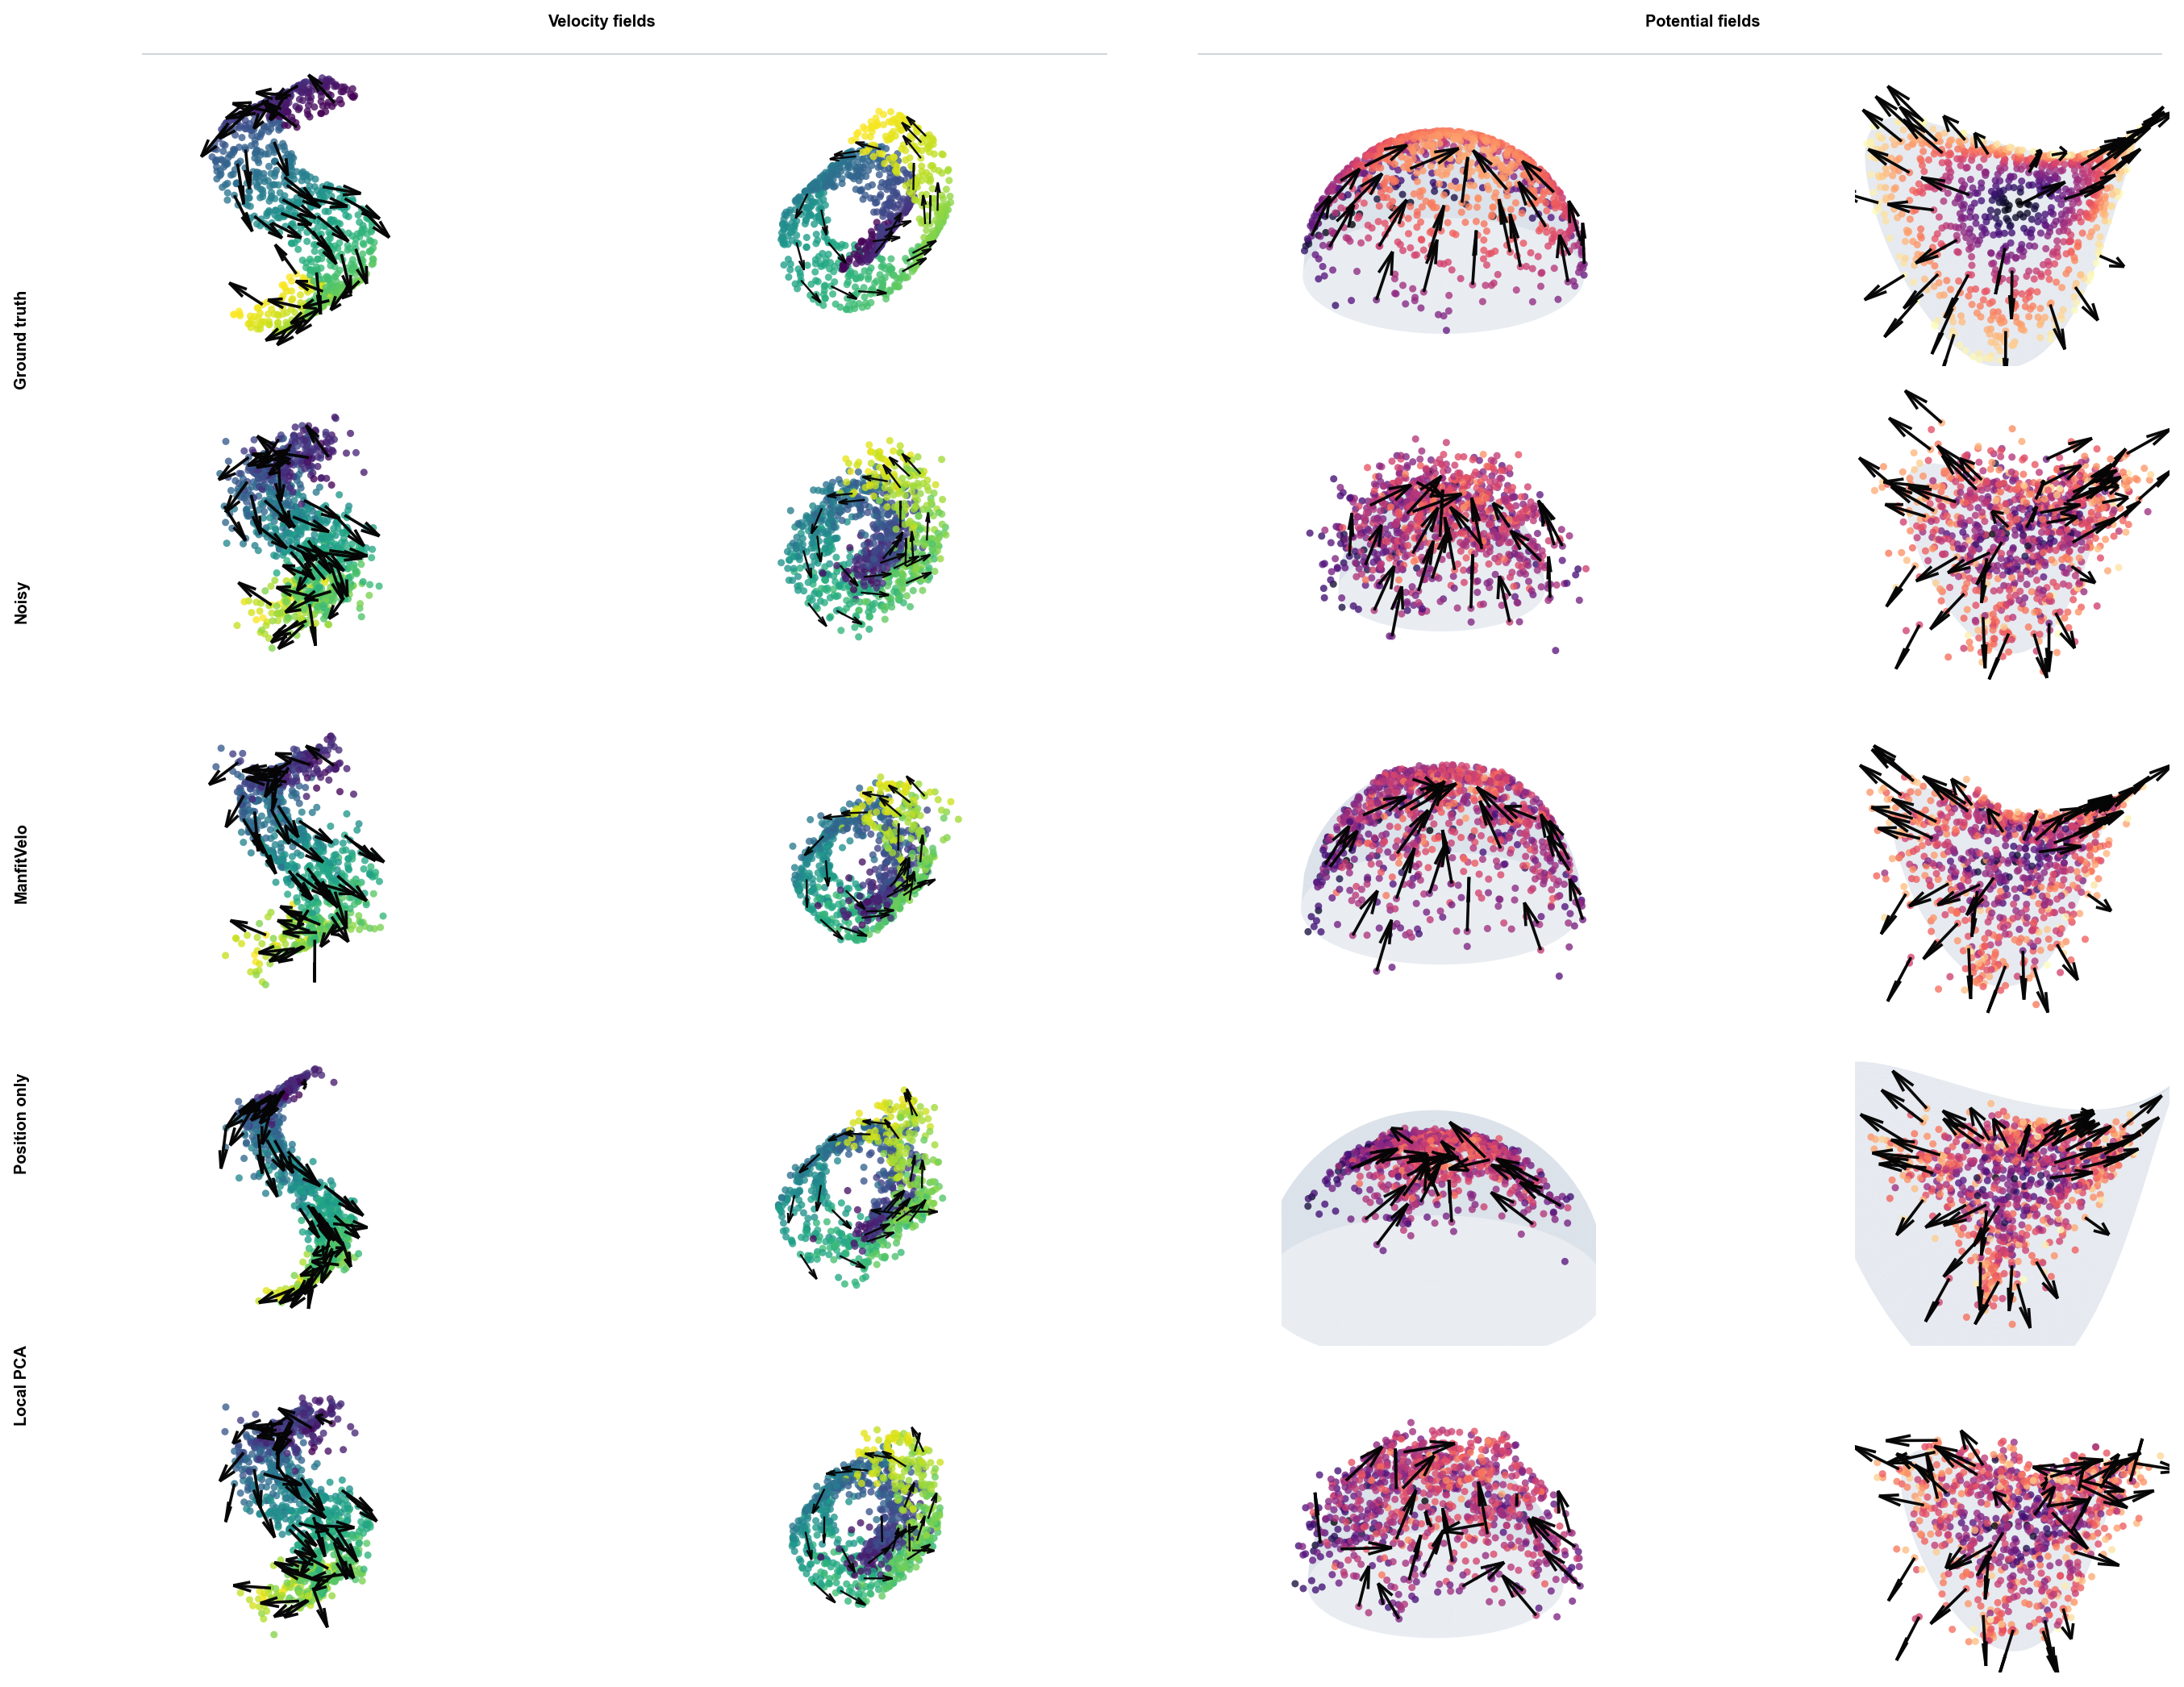

In [34]:
# One notebook grid for visual comparison.
comparison_rows = [
    ("Ground truth", clean_sims),
    ("Noisy", noisy_sims),
    ("ManfitVelo", manfitvelo_sims),
    ("Position only", position_only_sims),
    ("Local PCA", local_pca_sims),
]
fig = make_row_figure(comparison_rows)
plt.show()


## Export four slide-ready PDF panels

In [35]:
# Save the four clean 1x4 PDF panels used for slides/figures.
from scripts.plot_figure2_vector_fields_1x4 import METHODS, configure_matplotlib, default_output_base, render_panel

configure_matplotlib(dpi=600)
render_panel(DATA_DIR / "manifest.json", OUTPUT_DIR / "figure2_noisy_vector_fields_1x4_highres", dpi=600, layer="noisy", formats=("pdf",))
for method in METHODS:
    render_panel(OUTPUT_DIR / method / "manifest.json", default_output_base(OUTPUT_DIR, method), dpi=600, layer="fit", formats=("pdf",))


/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/figure2_noisy_vector_fields_1x4_highres.pdf
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/figure2_manfitvelo_vector_fields_1x4_highres.pdf
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/figure2_position_only_manfit_vector_fields_1x4_highres.pdf
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/figure2_local_pca_vector_fields_1x4_highres.pdf


## Manifold-projection distance metrics

In [36]:
from scripts.figure2_reconstruction_metrics import (
    compute_rows as compute_reconstruction_rows,
    write_outputs as write_reconstruction_outputs,
)
from scripts.figure2_manifold_projection_metrics import (
    compute_rows as compute_projection_rows,
    dataframe_to_markdown,
    write_outputs as write_projection_outputs,
)
from scripts.figure2_geometric_knn_metrics import (
    compute_rows as compute_geometric_rows,
    write_outputs as write_geometric_outputs,
)

reconstruction_table, reconstruction_parameters = compute_reconstruction_rows(OUTPUT_DIR)
projection_table, projection_parameters = compute_projection_rows(OUTPUT_DIR, grid_size=220)
geometric_table, geometric_parameters = compute_geometric_rows(OUTPUT_DIR, n_neighbors=25)

reconstruction_paths = write_reconstruction_outputs(reconstruction_table, reconstruction_parameters, OUTPUT_DIR / "metrics")
projection_paths = write_projection_outputs(projection_table, projection_parameters, OUTPUT_DIR / "metrics")
geometric_paths = write_geometric_outputs(geometric_table, geometric_parameters, OUTPUT_DIR / "metrics")

main_metric_table = reconstruction_table[
    ["dataset", "method", "position_relative_rmse", "velocity_relative_rmse"]
].merge(
    projection_table[["dataset", "method", "manifold_distance_relative_rmse"]],
    on=["dataset", "method"],
).merge(
    geometric_table[["dataset", "method", "velocity_angle_mae_relative"]],
    on=["dataset", "method"],
)
main_metric_table["dataset"] = main_metric_table["dataset"].replace({
    "s_curve_velocity_flow": "s_curve",
    "swiss_roll_velocity_flow": "swiss_roll",
    "half_sphere_single_basin": "half_sphere",
    "saddle_surface_single_basin": "saddle_surface",
})
main_metric_table = main_metric_table.rename(columns={
    "position_relative_rmse": "position_rmse_rel",
    "manifold_distance_relative_rmse": "manifold_distance_rel",
    "velocity_relative_rmse": "velocity_rmse_rel",
    "velocity_angle_mae_relative": "velocity_angle_mae_rel",
})
main_metric_table = main_metric_table[
    [
        "dataset",
        "method",
        "position_rmse_rel",
        "manifold_distance_rel",
        "velocity_rmse_rel",
        "velocity_angle_mae_rel",
    ]
]
metric_cols = [
    "position_rmse_rel",
    "manifold_distance_rel",
    "velocity_rmse_rel",
    "velocity_angle_mae_rel",
]
main_metric_table[metric_cols] = main_metric_table[metric_cols].round(4)

main_csv = OUTPUT_DIR / "metrics" / "figure2_main_metrics.csv"
main_md = OUTPUT_DIR / "metrics" / "figure2_main_metrics.md"
main_metric_table.to_csv(main_csv, index=False)
main_md.write_text(dataframe_to_markdown(main_metric_table) + "\n")

display(main_metric_table)
print(dataframe_to_markdown(main_metric_table))
{
    "main_csv": main_csv,
    "main_markdown": main_md,
    "reconstruction_metrics": reconstruction_paths,
    "projection_metrics": projection_paths,
    "geometric_metrics": geometric_paths,
}


,dataset,method,position_rmse_rel,manifold_distance_rel,pairwise_distance_error_rel,velocity_rmse_rel,velocity_angle_mae_rel
0,s_curve,Noisy,1.0000,1.0000,2.5586,1.0000,1.0000
1,s_curve,ManfitVelo,0.8654,0.6472,1.8744,3.9816,5.4262
2,s_curve,Position-only MANFIT,1.0430,0.6540,1.1221,7.2355,6.8595
3,s_curve,Local PCA,0.8889,0.7154,2.1489,7.1813,17.8335
4,swiss_roll,Noisy,1.0000,1.0000,0.8632,1.0000,1.0000
5,swiss_roll,ManfitVelo,1.1578,1.2381,0.6734,2.8945,3.4272
6,swiss_roll,Position-only MANFIT,1.1474,0.9913,0.6970,6.5992,10.2210
7,swiss_roll,Local PCA,0.9380,0.7883,0.7380,6.6614,12.2498
8,half_sphere,Noisy,1.0000,1.0000,3.0120,1.0000,1.0000
9,half_sphere,ManfitVelo,0.8384,0.4338,2.1842,2.7362,3.1169


| dataset        | method               | position_rmse_rel | manifold_distance_rel | pairwise_distance_error_rel | velocity_rmse_rel | velocity_angle_mae_rel |
| -------------- | -------------------- | ----------------- | --------------------- | --------------------------- | ----------------- | ---------------------- |
| s_curve        | Noisy                | 1.0               | 1.0                   | 2.5586                      | 1.0               | 1.0                    |
| s_curve        | ManfitVelo           | 0.8654            | 0.6472                | 1.8744                      | 3.9816            | 5.4262                 |
| s_curve        | Position-only MANFIT | 1.043             | 0.654                 | 1.1221                      | 7.2355            | 6.8595                 |
| s_curve        | Local PCA            | 0.8889            | 0.7154                | 2.1489                      | 7.1813            | 17.8335                |
| swiss_roll     | Noisy          

{'main_csv': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_main_metrics.csv'),
 'main_markdown': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_main_metrics.md'),
 'reconstruction_metrics': {'csv': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_reconstruction_metrics.csv'),
  'markdown': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_reconstruction_metrics.md'),
  'parameters': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_method_parameters.json')},
 'projection_metrics': {'csv': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_manifold_projection_metrics.csv'),
  'markdown': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/figure2_manifold_projection_metrics.md'),
  'parameters': PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/metrics/f

## Build the self-contained HTML report

Render the refreshed four-simulation panels and embed them with the metric table in one portable HTML file.

In [12]:
from scripts.build_figure2_html_report import build_html

html_report = OUTPUT_DIR / "figure2_visual_metrics_report.html"
build_html(OUTPUT_DIR, html_report, dpi=300, reuse_assets=False)
html_report

/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/html_assets/figure2_ground_truth_vector_fields_1x4_highres.png
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/html_assets/figure2_noisy_vector_fields_1x4_highres.png
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/html_assets/figure2_manfitvelo_vector_fields_1x4_highres.png
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/html_assets/figure2_position_only_manfit_vector_fields_1x4_highres.png
/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/html_assets/figure2_local_pca_vector_fields_1x4_highres.png


PosixPath('/Users/jh/Projects/ManfitVelo/outputs/figure2_pipeline/figure2_visual_metrics_report.html')